# S&P 500 Equity Option Analytics: Feature Evaluation

Consolidated evaluation of Ch8 financial features (45 IV/equity) and Ch9
temporal features (3 GARCH) against 5-day forward equity returns. Produces
triage decisions for Ch11 modeling.

This is the **authoritative holdout-clean feature evaluation** that
`03_financial_features.py` and `04_model_based_features.py` defer to: every
statistic below is computed on the pre-2021 development window only, with the
2021 holdout sealed out (see "Seal the holdout window" below). The 2021 holdout
is spent once, on the single selected model in Ch11 onward.

**Learning Objectives**:
- Evaluate IV-derived features for standalone predictive power on equity returns
- Apply HAC adjustment for overlapping 5-day return autocorrelation
- Control false discovery rate with Benjamini-Hochberg correction
- Report weak standalone IC plainly rather than overstating marginal signal

**Book Reference**: Chapter 8, Section 8.5 (Feature Evaluation)

**Prerequisites**: `03_financial_features.py` and `04_model_based_features.py`
must have run.

In [1]:
"""S&P 500 Equity Option Analytics: Feature Evaluation."""

import warnings

warnings.filterwarnings("ignore")

import numpy as np
import plotly.graph_objects as go
import polars as pl
from ml4t.diagnostic.evaluation.stats import benjamini_hochberg_fdr
from ml4t.diagnostic.metrics import compute_ic_hac_stats
from plotly.subplots import make_subplots
from scipy.stats import spearmanr

import utils.style as style
from utils.cv_splits import load_evaluation_config
from utils.paths import display_path, get_case_study_dir

# Register the ML4T Plotly template (colorway, fonts, gridlines) as the default
# and expose the book palette so every figure sources color from utils.style.
style.apply_ml4t_style()
COLORS = style.COLORS
GRAY_FILLS = style.GRAY_FILLS


def _normalize_asset_column(df: pl.DataFrame) -> pl.DataFrame:
    if "symbol" in df.columns:
        return df
    msg = f"Expected asset-like column in frame, found columns={df.columns}"
    raise KeyError(msg)

In [2]:
MAX_SYMBOLS = 0

In [3]:
CASE_STUDY_ID = "sp500_equity_option_analytics"
CASE_DIR = get_case_study_dir(CASE_STUDY_ID)
EVAL_DIR = CASE_DIR / "evaluation"
EVAL_DIR.mkdir(exist_ok=True)

PRIMARY_LABEL_FILE = "fwd_ret_5d.parquet"
HAC_MAXLAGS = 5  # 5-day forward return
LABEL_HORIZON_SESSIONS = 5  # P5D label - embargo width at the holdout seal
MIN_PERIODS = 20  # 415-634 symbols
IC_THRESHOLD = 0.005  # Weekly horizon
JOIN_COLS = ["timestamp", "symbol"]
DATE_COL = "timestamp"
# Metadata columns carried in the feature parquets that are NOT predictive features
# (mirrors the exclusion in utils.modeling so evaluation and modeling agree).
NON_FEATURE_COLS = {"fold", "is_holdout"}

## 0. Load Artifacts & Build Evaluation Panel

Load features (45 IV/equity), temporal (3 GARCH per symbol), and labels.
Both features and temporal have a symbol column, so we join on [date, symbol].
The `fold` metadata column in the temporal parquet is not a feature and is
dropped here (`NON_FEATURE_COLS`), matching how `utils.modeling` builds the
modeling dataset.

In [4]:
features = _normalize_asset_column(pl.read_parquet(CASE_DIR / "features" / "financial.parquet"))
temporal = _normalize_asset_column(pl.read_parquet(CASE_DIR / "features" / "model_based.parquet"))

label_df = pl.read_parquet(CASE_DIR / "labels" / PRIMARY_LABEL_FILE)
label_col = [c for c in label_df.columns if c not in ("timestamp", "symbol", "timestamp")][0]

cv_config = load_evaluation_config(CASE_STUDY_ID)

print(f"Features: {features.shape}")
print(f"Temporal: {temporal.shape}")
print(f"Labels: {label_df.shape}, column: {label_col}")

Features: (530503, 47)
Temporal: (1091740, 6)
Labels: (632522, 3), column: fwd_ret_5d


In [5]:
financial_cols = [c for c in features.columns if c not in JOIN_COLS and c not in NON_FEATURE_COLS]
temporal_cols = [c for c in temporal.columns if c not in JOIN_COLS and c not in NON_FEATURE_COLS]

# Join: features + temporal (both have symbol) + labels
eval_panel = features.join(temporal, on=JOIN_COLS, how="left")
eval_panel = eval_panel.join(label_df, on=JOIN_COLS, how="inner")

all_feature_cols = financial_cols + temporal_cols

if MAX_SYMBOLS > 0:
    top = eval_panel.group_by("symbol").len().sort("len", descending=True).head(MAX_SYMBOLS)
    eval_panel = eval_panel.filter(pl.col("symbol").is_in(top["symbol"]))

### Seal the holdout window

03 and 04 defer to this notebook as *the authoritative holdout-clean feature
evaluation*. To honor that, every statistic below (coverage/staleness, IC, HAC,
FDR, fold stability, triage) is computed on the **development window only** --
sessions strictly before the 2021 holdout, with the final
`LABEL_HORIZON_SESSIONS` dev sessions embargoed so no 5-day forward label
reaches across the seal. The 2021 holdout is never read here; it is spent once,
on the single selected model in Ch11 onward.

In [6]:
from datetime import date as _date

holdout_start = str(cv_config["holdout_start"])[:10]
holdout_start_date = _date.fromisoformat(holdout_start)

dev_sessions = eval_panel.filter(pl.col(DATE_COL) < holdout_start_date)[DATE_COL].unique().sort()
if dev_sessions.len() > LABEL_HORIZON_SESSIONS:
    embargo_cutoff = dev_sessions[-(LABEL_HORIZON_SESSIONS + 1)]
    eval_panel = eval_panel.filter(pl.col(DATE_COL) <= embargo_cutoff)
else:
    eval_panel = eval_panel.filter(pl.col(DATE_COL) < holdout_start_date)

print(
    f"Holdout sealed at {holdout_start}: evaluating "
    f"{eval_panel[DATE_COL].min()} -> {eval_panel[DATE_COL].max()} "
    f"({eval_panel[DATE_COL].n_unique():,} dev sessions, "
    f"{LABEL_HORIZON_SESSIONS}-session label embargo)"
)

n_rows = len(eval_panel)
n_symbols = eval_panel["symbol"].n_unique()
n_dates = eval_panel[DATE_COL].n_unique()
print(f"\nEval panel: {n_rows:,} rows, {n_symbols} symbols, {n_dates:,} dates")
print(
    f"Features: {len(financial_cols)} financial + {len(temporal_cols)} temporal"
    f" = {len(all_feature_cols)} total"
)
print(f"Label: {label_col}")

Holdout sealed at 2021-01-01: evaluating 2017-01-03 -> 2020-12-23 (1,002 dev sessions, 5-session label embargo)

Eval panel: 819,579 rows, 609 symbols, 1,002 dates
Features: 45 financial + 3 temporal = 48 total
Label: fwd_ret_5d


## 0.5 Data Quality Gate

Verify upstream artifacts are free of critical defects before evaluation.

In [7]:
from utils.data_quality import validate_modeling_inputs

validate_modeling_inputs(
    features_df=eval_panel,
    label_df=eval_panel,
    feature_cols=all_feature_cols,
    label_col=label_col,
    join_cols=JOIN_COLS,
    asset_col="symbol",
    max_abs_return=10.0,  # 5-day equity returns (max observed ~6.83, small caps)
    fail_on_critical=True,
)

Data Quality Gate: ALL CLEAR


{'issues': [], 'n_critical': 0, 'n_warning': 0}

## 1. Correctness Screens

Check coverage and staleness before evaluating predictive power.
IV features may have reduced coverage for less-liquid names. The 1-day IV
lag by construction means features are slightly stale; this is expected
and not flagged as a problem.

In [8]:
coverage = {}
staleness = {}

for feat in all_feature_cols:
    col = eval_panel[feat]
    coverage[feat] = col.drop_nulls().len() / n_rows

    unchanged = (
        eval_panel.sort(JOIN_COLS)
        .select((pl.col(feat) == pl.col(feat).shift(1).over("symbol")).alias("same"))["same"]
        .sum()
    )
    staleness[feat] = float(unchanged) / max(n_rows - n_symbols, 1)

correctness = {
    feat: coverage[feat] >= 0.70 and staleness[feat] <= 0.50 for feat in all_feature_cols
}
n_pass = sum(correctness.values())
n_fail = len(correctness) - n_pass
print(f"Correctness gate: {n_pass} PASS, {n_fail} FAIL")

if n_fail > 0:
    fail_df = pl.DataFrame(
        {
            "feature": [f for f, ok in correctness.items() if not ok],
            "coverage": [round(coverage[f], 3) for f, ok in correctness.items() if not ok],
            "staleness": [round(staleness[f], 3) for f, ok in correctness.items() if not ok],
        }
    )
    print(fail_df)

Correctness gate: 27 PASS, 21 FAIL
shape: (21, 3)
┌───────────────────┬──────────┬───────────┐
│ feature           ┆ coverage ┆ staleness │
│ ---               ┆ ---      ┆ ---       │
│ str               ┆ f64      ┆ f64       │
╞═══════════════════╪══════════╪═══════════╡
│ iv_30_atm         ┆ 0.914    ┆ 0.513     │
│ iv_7_atm          ┆ 0.857    ┆ 0.552     │
│ iv_90_atm         ┆ 0.628    ┆ 0.358     │
│ iv_30_put_25d     ┆ 0.914    ┆ 0.513     │
│ iv_30_call_25d    ┆ 0.914    ┆ 0.513     │
│ …                 ┆ …        ┆ …         │
│ iv_30_atm_pct_252 ┆ 0.497    ┆ 0.286     │
│ term_ratio_z_63   ┆ 0.024    ┆ 0.011     │
│ vrp_z_63          ┆ 0.577    ┆ 0.301     │
│ mom_63d_rank      ┆ 0.963    ┆ 0.5       │
│ rv_rank           ┆ 0.988    ┆ 0.509     │
└───────────────────┴──────────┴───────────┘


## 2. Univariate Association (IC + HAC)

Cross-sectional Spearman IC with HAC adjustment (bandwidth = 5 trading days
for the 5-day forward return label). Date-level features (identical across
symbols) produce zero CS-IC by construction and are flagged separately.

In [9]:
evaluable_features = [f for f in all_feature_cols if correctness[f]]

# Detect date-level features (zero cross-sectional variance)
cs_std_df = eval_panel.group_by(DATE_COL).agg(
    [pl.col(f).std().alias(f) for f in evaluable_features]
)
date_level_features = set()
for feat in evaluable_features:
    mean_std = cs_std_df[feat].drop_nulls().mean()
    if mean_std is not None and mean_std < 1e-10:
        date_level_features.add(feat)

if date_level_features:
    print(f"Date-level features (zero CS variance): {sorted(date_level_features)}")

In [10]:
# Batch IC computation: one pass over dates, all features at once
cs_features = [f for f in evaluable_features if f not in date_level_features]
cols_needed = [DATE_COL] + cs_features + [label_col]
eval_sub = eval_panel.select(cols_needed).drop_nulls(subset=[label_col])

dates_list = eval_sub[DATE_COL].unique().sort().to_list()
n_total = len(dates_list)

ic_series_data = {feat: [] for feat in cs_features}

for i, dt in enumerate(dates_list):
    cross_section = eval_sub.filter(pl.col(DATE_COL) == dt)
    n_obs = len(cross_section)
    if n_obs < MIN_PERIODS:
        continue

    label_arr = cross_section[label_col].to_numpy()
    label_valid = ~np.isnan(label_arr)

    for feat in cs_features:
        feat_arr = cross_section[feat].to_numpy()
        valid_mask = label_valid & ~np.isnan(feat_arr)
        n_valid = int(valid_mask.sum())
        if n_valid >= MIN_PERIODS:
            ic_val, _ = spearmanr(feat_arr[valid_mask], label_arr[valid_mask])
            if not np.isnan(ic_val):
                ic_series_data[feat].append((dt, float(ic_val), n_valid))

    if (i + 1) % 200 == 0:
        print(f"  IC progress: {i + 1}/{n_total} dates")

print(f"  IC progress: {n_total}/{n_total} dates (done)")

  IC progress: 200/1002 dates


  IC progress: 400/1002 dates


  IC progress: 600/1002 dates


  IC progress: 800/1002 dates


  IC progress: 1000/1002 dates
  IC progress: 1002/1002 dates (done)


In [11]:
# Convert to DataFrames and compute HAC stats
ic_results = {}
ic_timeseries = {}
for feat in cs_features:
    data = ic_series_data[feat]
    if len(data) < 20:
        continue
    dates_f, ics_f, nobs_f = zip(*data, strict=False)
    ic_df = pl.DataFrame({DATE_COL: list(dates_f), "ic": list(ics_f), "n_obs": list(nobs_f)})
    hac_stats = compute_ic_hac_stats(ic_df, ic_col="ic", maxlags=HAC_MAXLAGS)
    ic_results[feat] = hac_stats
    ic_timeseries[feat] = ic_df

print(f"IC computed for {len(ic_results)} cross-sectional features")
print(f"Skipped {len(date_level_features)} date-level features")

IC computed for 27 cross-sectional features
Skipped 0 date-level features


### Fold-Level Stability

With only 2 CV folds (data-constrained), sign consistency is limited.
We still compute it but note the low statistical power.

In [12]:
# Use actual CV fold test boundaries from cv_config (not equal partitioning)
cv_splits = cv_config.get("splits", [])
if cv_splits:
    from datetime import date as dt_date

    fold_boundaries = [
        (
            dt_date.fromisoformat(str(s["val_start"])[:10]),
            dt_date.fromisoformat(str(s["val_end"])[:10]),
        )
        for s in cv_splits
    ]
else:
    # Fallback: equal partitioning
    all_dates = eval_panel[DATE_COL].unique().sort().to_list()
    n_folds = cv_config.get("n_splits", 2)
    fold_size = len(all_dates) // n_folds
    fold_boundaries = []
    for i in range(n_folds):
        start_idx = i * fold_size
        end_idx = min((i + 1) * fold_size - 1, len(all_dates) - 1)
        fold_boundaries.append((all_dates[start_idx], all_dates[end_idx]))

fold_stats = {}
for feat in ic_results:
    fold_ics = []
    ts = ic_timeseries[feat]
    for fold_start, fold_end in fold_boundaries:
        fold_ic = ts.filter((pl.col(DATE_COL) >= fold_start) & (pl.col(DATE_COL) <= fold_end))
        if len(fold_ic) >= 5:
            fold_ics.append(float(fold_ic["ic"].mean()))

    if fold_ics:
        sign_consistency = sum(1 for ic in fold_ics if ic > 0) / len(fold_ics)
        fold_stats[feat] = {
            "n_folds": len(fold_ics),
            "sign_consistency": sign_consistency,
            "worst_fold_ic": min(fold_ics),
            "best_fold_ic": max(fold_ics),
            "median_fold_ic": float(np.median(fold_ics)),
        }

print(f"Fold stability computed for {len(fold_stats)} features")

Fold stability computed for 27 features


## 3. Multiple Testing (BH-FDR)

With 27 features clearing the correctness screen, naive testing at
$\alpha = 0.05$ expects ~1 false positive. The BH-FDR correction controls the
false discovery rate.

**Note**: Zero (or very few) FDR-significant features is the expected result
for this case study. IV features have weak standalone IC against equity
returns; their value emerges through multivariate interactions in Ch11.

In [13]:
feature_names = list(ic_results.keys())
p_values = [ic_results[f]["p_value"] for f in feature_names]

fdr_result = benjamini_hochberg_fdr(p_values, alpha=0.05, return_details=True)

eval_summary = pl.DataFrame(
    {
        "feature": feature_names,
        "source": ["temporal" if f in temporal_cols else "financial" for f in feature_names],
        "ic_mean": [ic_results[f]["mean_ic"] for f in feature_names],
        "hac_se": [ic_results[f]["hac_se"] for f in feature_names],
        "hac_t": [ic_results[f]["t_stat"] for f in feature_names],
        "hac_p": p_values,
        "fdr_p": [float(p) for p in fdr_result["adjusted_p_values"]],
        "fdr_sig": [bool(r) for r in fdr_result["rejected"]],
        "naive_t": [ic_results[f]["naive_t_stat"] for f in feature_names],
    },
    schema_overrides={
        "ic_mean": pl.Float64,
        "hac_se": pl.Float64,
        "hac_t": pl.Float64,
        "hac_p": pl.Float64,
        "fdr_p": pl.Float64,
        "fdr_sig": pl.Boolean,
        "naive_t": pl.Float64,
    },
).sort(pl.col("ic_mean").cast(pl.Float64, strict=False).abs(), descending=True)

n_significant_naive = sum(1 for p in p_values if p < 0.05)
n_significant_hac = sum(1 for f in feature_names if abs(ic_results[f]["t_stat"]) > 1.96)
n_significant_fdr = int(fdr_result["n_rejected"])

inflation_hac = n_significant_naive / max(n_significant_hac, 1)
inflation_fdr = n_significant_naive / max(n_significant_fdr, 1)

print(f"Features tested: {len(feature_names)}")
print(f"Naive significant (p < 0.05): {n_significant_naive}")
print(f"HAC significant (|t| > 1.96): {n_significant_hac}")
print(f"FDR significant (q < 0.05):   {n_significant_fdr}")
print(f"Inflation factor (HAC): {inflation_hac:.2f}x")
print(f"Inflation factor (FDR): {inflation_fdr:.2f}x")

Features tested: 27
Naive significant (p < 0.05): 1
HAC significant (|t| > 1.96): 1
FDR significant (q < 0.05):   0
Inflation factor (HAC): 1.00x
Inflation factor (FDR): 1.00x


In [14]:
print("\nTop 15 features by absolute IC:")
print(eval_summary.head(15))


Top 15 features by absolute IC:
shape: (15, 9)
┌───────────────┬───────────┬───────────┬──────────┬───┬──────────┬──────────┬─────────┬───────────┐
│ feature       ┆ source    ┆ ic_mean   ┆ hac_se   ┆ … ┆ hac_p    ┆ fdr_p    ┆ fdr_sig ┆ naive_t   │
│ ---           ┆ ---       ┆ ---       ┆ ---      ┆   ┆ ---      ┆ ---      ┆ ---     ┆ ---       │
│ str           ┆ str       ┆ f64       ┆ f64      ┆   ┆ f64      ┆ f64      ┆ bool    ┆ f64       │
╞═══════════════╪═══════════╪═══════════╪══════════╪═══╪══════════╪══════════╪═════════╪═══════════╡
│ mom_5d        ┆ financial ┆ -0.015576 ┆ 0.010628 ┆ … ┆ 0.14311  ┆ 0.921688 ┆ false   ┆ -2.516555 │
│ term_slope_ne ┆ financial ┆ 0.012573  ┆ 0.005011 ┆ … ┆ 0.012264 ┆ 0.331139 ┆ false   ┆ 4.030195  │
│ ar_atm        ┆           ┆           ┆          ┆   ┆          ┆          ┆         ┆           │
│ rv_63         ┆ financial ┆ -0.011777 ┆ 0.014919 ┆ … ┆ 0.430097 ┆ 0.921688 ┆ false   ┆ -1.425401 │
│ mom_skip_rece ┆ financial ┆ 0.01174   ┆ 0

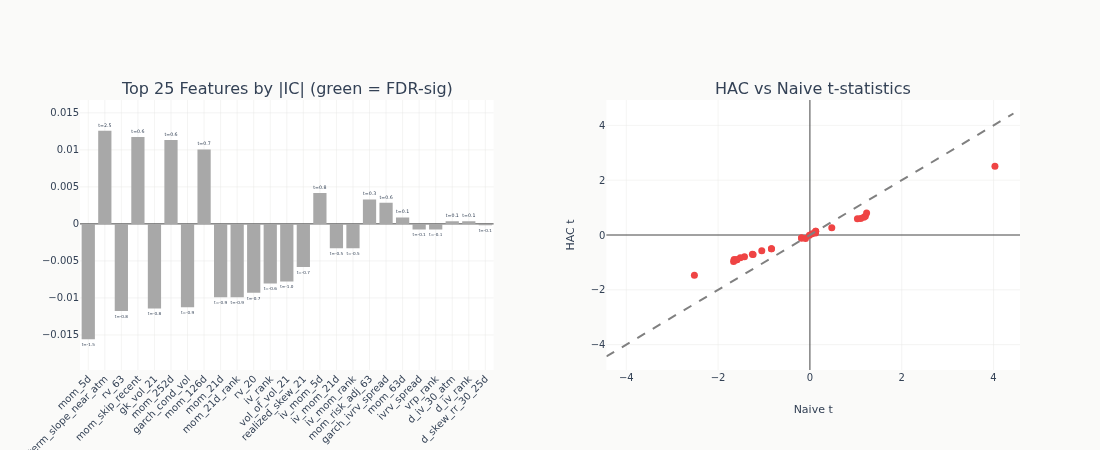

In [15]:
top_n = min(25, len(eval_summary))
top = eval_summary.head(top_n)

fig = make_subplots(
    rows=1,
    cols=2,
    subplot_titles=[
        f"Top {top_n} Features by |IC| (green = FDR-sig)",
        "HAC vs Naive t-statistics",
    ],
    horizontal_spacing=0.12,
)

colors = [COLORS["positive"] if s else GRAY_FILLS["muted"] for s in top["fdr_sig"].to_list()]
fig.add_trace(
    go.Bar(
        x=top["feature"].to_list(),
        y=top["ic_mean"].to_list(),
        marker_color=colors,
        text=[f"t={t:.1f}" for t in top["hac_t"].to_list()],
        textposition="outside",
        showlegend=False,
    ),
    row=1,
    col=1,
)

fig.add_trace(
    go.Scatter(
        x=eval_summary["naive_t"].to_list(),
        y=eval_summary["hac_t"].to_list(),
        mode="markers",
        marker=dict(
            color=[
                COLORS["positive"] if s else COLORS["negative"]
                for s in eval_summary["fdr_sig"].to_list()
            ],
            size=7,
        ),
        text=eval_summary["feature"].to_list(),
        showlegend=False,
    ),
    row=1,
    col=2,
)
max_t = (
    max(
        eval_summary["naive_t"].cast(pl.Float64, strict=False).abs().max() or 1.0,
        eval_summary["hac_t"].cast(pl.Float64, strict=False).abs().max() or 1.0,
    )
    * 1.1
)
fig.add_trace(
    go.Scatter(
        x=[-max_t, max_t],
        y=[-max_t, max_t],
        mode="lines",
        line=dict(dash="dash", color="gray"),
        showlegend=False,
    ),
    row=1,
    col=2,
)

fig.update_layout(template="ml4t", height=450, width=1100)
fig.update_xaxes(tickangle=-45, row=1, col=1)
fig.update_xaxes(title_text="Naive t", row=1, col=2)
fig.update_yaxes(title_text="HAC t", row=1, col=2)
fig.show()

**Interpretation**: IV-derived features have weak standalone cross-sectional IC
against equity returns. This is expected: implied volatility primarily predicts
future realized volatility, not the direction of equity returns. The value of
these features lies in:
1. **Multivariate interactions**: IV combined with momentum in Ch11
2. **Regime conditioning**: IV signals work differently in high/low VIX environments
3. **VRP timing**: The variance risk premium predicts aggregate returns better
   than individual stock returns

## 4. Shape Diagnostics

Quantile monotonicity for top features.

In [16]:
N_QUANTILES = 5
top_features_for_shape = eval_summary.filter(pl.col("fdr_sig").fill_null(False))[
    "feature"
].to_list()[:15]
if not top_features_for_shape:
    top_features_for_shape = eval_summary.head(10)["feature"].to_list()

monotonicity_scores = {}
quantile_spreads = {}

for feat in top_features_for_shape:
    valid = eval_panel.select([feat, label_col]).drop_nulls()
    if len(valid) < N_QUANTILES * 20:
        continue

    valid = valid.with_columns(
        pl.col(feat)
        .qcut(N_QUANTILES, labels=[f"Q{i + 1}" for i in range(N_QUANTILES)])
        .alias("quantile")
    )
    q_means = valid.group_by("quantile").agg(pl.col(label_col).mean()).sort("quantile")
    means = q_means[label_col].to_list()
    spread = means[-1] - means[0]
    quantile_spreads[feat] = {"q_means": means, "spread": spread}

    mono_corr, _ = spearmanr(range(len(means)), means)
    monotonicity_scores[feat] = float(mono_corr)

print(f"Shape analysis for {len(quantile_spreads)} features")

Shape analysis for 10 features


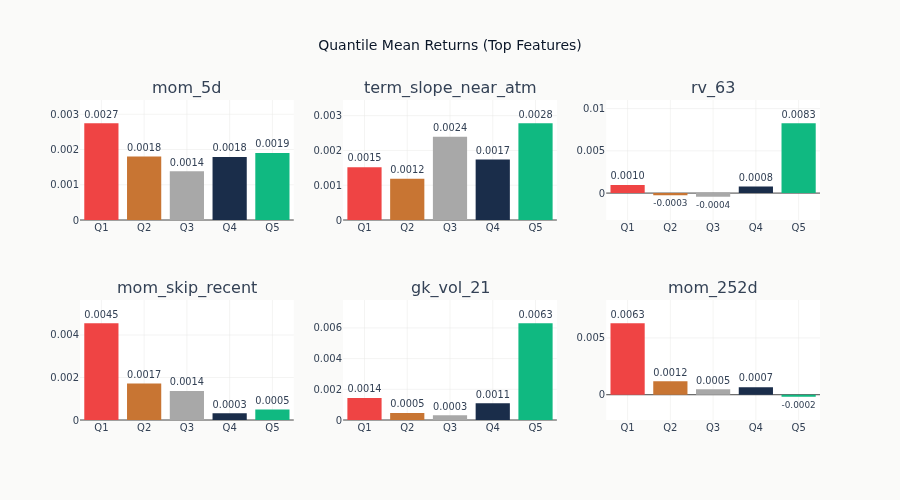

In [17]:
if quantile_spreads:
    n_show = min(6, len(quantile_spreads))
    feats_to_show = list(quantile_spreads.keys())[:n_show]
    n_rows_fig = (n_show + 2) // 3
    fig = make_subplots(rows=n_rows_fig, cols=3, subplot_titles=feats_to_show)
    for idx, feat in enumerate(feats_to_show):
        r, c = divmod(idx, 3)
        q_means = quantile_spreads[feat]["q_means"]
        fig.add_trace(
            go.Bar(
                x=[f"Q{i + 1}" for i in range(len(q_means))],
                y=q_means,
                marker_color=[
                    COLORS["negative"],
                    COLORS["copper"],
                    GRAY_FILLS["muted"],
                    COLORS["slate"],
                    COLORS["positive"],
                ],
                showlegend=False,
                text=[f"{m:.4f}" for m in q_means],
                textposition="outside",
            ),
            row=r + 1,
            col=c + 1,
        )
    fig.update_layout(
        template="ml4t",
        height=250 * n_rows_fig,
        width=900,
        title_text="Quantile Mean Returns (Top Features)",
    )
    fig.show()

## 5. Redundancy & Feature Families

In [18]:
def assign_feature_family(col: str) -> str:
    """Map feature name to family - canonical prefix-based logic matching 03_financial_features.py."""
    if col.startswith(("iv_30", "iv_7", "iv_90", "d_iv", "iv_mom")):
        return "iv_level_dynamics"
    elif col.startswith(("skew", "term", "iv_30_put", "iv_30_call")):
        return "skew_term"
    elif col.startswith(("rv_", "ivrv", "vrp", "gk_vol", "vol_of_vol", "realized_skew")):
        return "vrp"
    elif col.endswith("_rank"):
        return "cross_sectional_rank"
    elif col.startswith("mom_"):
        return "momentum"
    elif col.startswith(("qc_", "spread_")):
        return "quality"
    elif col.startswith("garch_"):
        return "temporal_garch"
    return "other"


families = {feat: assign_feature_family(feat) for feat in all_feature_cols}

for feat in temporal_cols:
    families[feat] = assign_feature_family(feat)

In [19]:
# Pairwise correlation
sample_step = max(1, n_dates // 200)
sample_dates = eval_panel[DATE_COL].unique().sort().to_list()[::sample_step]
corr_data = (
    eval_panel.filter(pl.col(DATE_COL).is_in(sample_dates)).select(evaluable_features).to_pandas()
)
corr_matrix = corr_data.corr(method="spearman")

high_corr_pairs = []
cols = corr_matrix.columns
for i in range(len(cols)):
    for j in range(i + 1, len(cols)):
        if abs(corr_matrix.iloc[i, j]) > 0.7:
            high_corr_pairs.append((cols[i], cols[j], float(corr_matrix.iloc[i, j])))

print(f"Feature pairs with |corr| > 0.7: {len(high_corr_pairs)}")

Feature pairs with |corr| > 0.7: 13


In [20]:
# Family-level IC summary
family_ic = {}
fdr_sig_set = set(eval_summary.filter(pl.col("fdr_sig").fill_null(False))["feature"].to_list())

for feat in ic_results:
    fam = families.get(feat, "other")
    family_ic.setdefault(fam, []).append(
        {
            "feature": feat,
            "ic": ic_results[feat]["mean_ic"],
            "fdr_sig": feat in fdr_sig_set,
        }
    )

family_summary = {}
for fam, feats in sorted(family_ic.items()):
    ics = [f["ic"] for f in feats if f["ic"] is not None]
    n_sig = sum(1 for f in feats if f["fdr_sig"])
    family_summary[fam] = {
        "n_features": len(feats),
        "avg_abs_ic": float(np.mean([abs(ic) for ic in ics])) if ics else 0.0,
        "avg_ic": float(np.mean(ics)) if ics else 0.0,
        "n_fdr_sig": n_sig,
    }

if family_summary:
    fam_df = pl.DataFrame([{"family": fam, **stats} for fam, stats in family_summary.items()]).sort(
        "avg_abs_ic", descending=True
    )
    print(fam_df)
else:
    fam_df = pl.DataFrame()
    print("No features passed IC evaluation threshold")

shape: (7, 5)
┌──────────────────────┬────────────┬────────────┬───────────┬───────────┐
│ family               ┆ n_features ┆ avg_abs_ic ┆ avg_ic    ┆ n_fdr_sig │
│ ---                  ┆ ---        ┆ ---        ┆ ---       ┆ ---       │
│ str                  ┆ i64        ┆ f64        ┆ f64       ┆ i64       │
╞══════════════════════╪════════════╪════════════╪═══════════╪═══════════╡
│ cross_sectional_rank ┆ 2          ┆ 0.008982   ┆ -0.008982 ┆ 0         │
│ momentum             ┆ 7          ┆ 0.008962   ┆ 0.001681  ┆ 0         │
│ vrp                  ┆ 7          ┆ 0.006803   ┆ -0.006803 ┆ 0         │
│ skew_term            ┆ 2          ┆ 0.006304   ┆ 0.006268  ┆ 0         │
│ temporal_garch       ┆ 3          ┆ 0.004759   ┆ -0.002755 ┆ 0         │
│ iv_level_dynamics    ┆ 5          ┆ 0.002298   ┆ -0.000335 ┆ 0         │
│ other                ┆ 1          ┆ 0.000188   ┆ -0.000188 ┆ 0         │
└──────────────────────┴────────────┴────────────┴───────────┴───────────┘


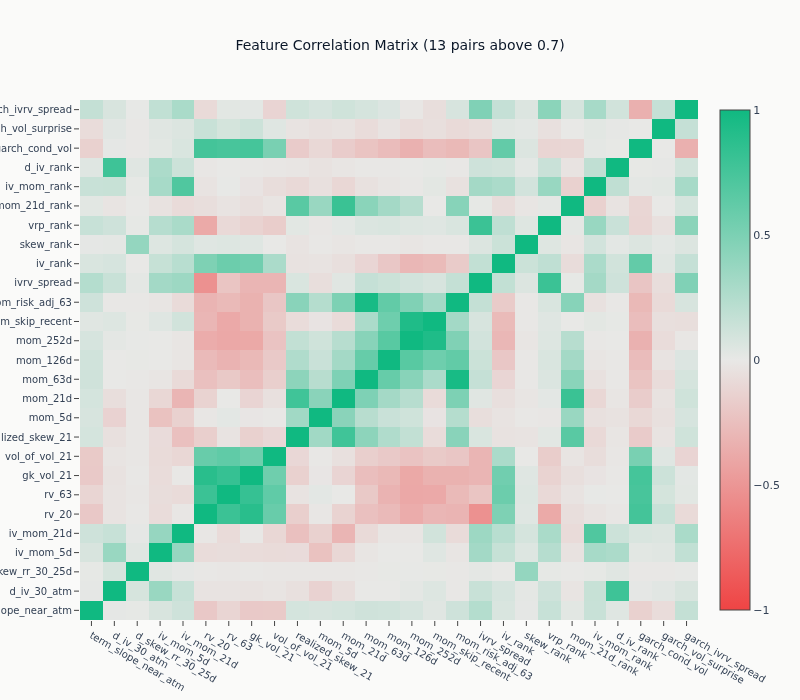

In [21]:
# Diverging colorscale sourced from the ML4T palette (negative -> neutral -> positive)
_div = style.ml4t_diverging()
ml4t_corr_scale = [[0.0, _div[0]], [0.5, _div[1]], [1.0, _div[2]]]
fig = go.Figure(
    data=go.Heatmap(
        z=corr_matrix.values,
        x=corr_matrix.columns.tolist(),
        y=corr_matrix.columns.tolist(),
        colorscale=ml4t_corr_scale,
        zmid=0,
        zmin=-1,
        zmax=1,
    )
)
fig.update_layout(
    title=f"Feature Correlation Matrix ({len(high_corr_pairs)} pairs above 0.7)",
    template="ml4t",
    height=700,
    width=800,
)
fig.show()

**Interpretation**: IV surface features (ATM vols, skew, term structure) form
a highly correlated block. VRP features (IV minus realized) are moderately
correlated with both surface and realized vol families. Downstream modeling
should cluster within families to reduce redundancy.

## 6. Triage & Handoff

| Decision | Criteria |
|----------|----------|
| **PROCEED** | FDR-significant OR (sign consistent > 60% AND abs(IC) > 0.005) |
| **STOP** | Correctness failure |
| **REVISE** | Everything else |

In [22]:
triage = {}
for feat in all_feature_cols:
    if not correctness[feat]:
        triage[feat] = ("STOP", "correctness_fail")
        continue

    if feat in date_level_features:
        triage[feat] = ("REVISE", "date_level_feature")
        continue

    if feat not in ic_results:
        triage[feat] = ("REVISE", "insufficient_data")
        continue

    is_fdr_sig = feat in fdr_sig_set
    sign_con = fold_stats.get(feat, {}).get("sign_consistency", 0)
    abs_ic = abs(ic_results[feat]["mean_ic"])

    if is_fdr_sig:
        triage[feat] = ("PROCEED", "fdr_significant")
    elif sign_con >= 0.60 and abs_ic >= IC_THRESHOLD:
        triage[feat] = ("PROCEED", "stable_and_above_threshold")
    else:
        triage[feat] = ("REVISE", "not_significant_standalone")

In [23]:
# Build triage ledger
ledger_rows = []
for feat in all_feature_cols:
    decision, note = triage[feat]
    row = {
        "feature": feat,
        "family": families.get(feat, "other"),
        "source": "temporal" if feat in temporal_cols else "financial",
        "ic_mean": ic_results.get(feat, {}).get("mean_ic"),
        "hac_t": ic_results.get(feat, {}).get("t_stat"),
        "hac_p": ic_results.get(feat, {}).get("p_value"),
        "fdr_p": None,
        "fdr_sig": False,
        "sign_consistency": fold_stats.get(feat, {}).get("sign_consistency"),
        "worst_fold_ic": fold_stats.get(feat, {}).get("worst_fold_ic"),
        "monotonicity": monotonicity_scores.get(feat),
        "coverage": coverage[feat],
        "staleness": staleness[feat],
        "decision": decision,
        "note": note,
    }
    match = eval_summary.filter(pl.col("feature") == feat)
    if len(match) > 0:
        row["fdr_p"] = float(match["fdr_p"][0])
        row["fdr_sig"] = bool(match["fdr_sig"][0])
    ledger_rows.append(row)

triage_ledger = pl.DataFrame(ledger_rows)
triage_ledger.write_parquet(EVAL_DIR / "triage_ledger.parquet")
print(f"Triage ledger saved: {display_path(EVAL_DIR / 'triage_ledger.parquet')}")
print(triage_ledger.group_by("decision").len().sort("decision"))

Triage ledger saved: case_studies/sp500_equity_option_analytics/evaluation/triage_ledger.parquet
shape: (3, 2)
┌──────────┬─────┐
│ decision ┆ len │
│ ---      ┆ --- │
│ str      ┆ u32 │
╞══════════╪═════╡
│ PROCEED  ┆ 4   │
│ REVISE   ┆ 23  │
│ STOP     ┆ 21  │
└──────────┴─────┘


In [24]:
# Save IC time series (long format)
ic_ts_frames = []
for feat, ts in ic_timeseries.items():
    ic_ts_frames.append(ts.with_columns(pl.lit(feat).alias("feature")))

if ic_ts_frames:
    ic_ts_all = pl.concat(ic_ts_frames)
    ic_ts_all.write_parquet(EVAL_DIR / "ic_timeseries.parquet")
    print(f"IC time series saved: {display_path(EVAL_DIR / 'ic_timeseries.parquet')}")

IC time series saved: case_studies/sp500_equity_option_analytics/evaluation/ic_timeseries.parquet


In [25]:
# Write results JSON
proceed_features = sorted(f for f, (d, _) in triage.items() if d == "PROCEED")
revise_features = [f for f, (d, _) in triage.items() if d == "REVISE"]
stop_features = [f for f, (d, _) in triage.items() if d == "STOP"]

sorted_by_ic = sorted(ic_results.items(), key=lambda x: x[1].get("mean_ic") or 0, reverse=True)
best = sorted_by_ic[0] if sorted_by_ic else ("n/a", {})
worst = sorted_by_ic[-1] if sorted_by_ic else ("n/a", {})

In [26]:
print(f"\n{'=' * 60}")
print(f"TRIAGE SUMMARY: {CASE_STUDY_ID}")
print(f"{'=' * 60}")
print(f"  PROCEED: {len(proceed_features)} features")
print(f"  REVISE:  {len(revise_features)} features")
print(f"  STOP:    {len(stop_features)} features")
print("\nPROMOTED (PROCEED) features:")
for f in proceed_features:
    ic = ic_results[f]["mean_ic"]
    t = ic_results[f]["t_stat"]
    print(f"  {f:40s}  IC={ic:+.4f}  t={t:.2f}  [{families.get(f, '?')}]")


TRIAGE SUMMARY: sp500_equity_option_analytics
  PROCEED: 4 features
  REVISE:  23 features
  STOP:    21 features

PROMOTED (PROCEED) features:
  mom_126d                                  IC=+0.0100  t=0.68  [momentum]
  mom_252d                                  IC=+0.0113  t=0.61  [momentum]
  mom_skip_recent                           IC=+0.0117  t=0.65  [momentum]
  term_slope_near_atm                       IC=+0.0126  t=2.51  [skew_term]


### Interpretation

The triage promotes features to PROCEED on sign consistency and IC threshold
rather than FDR significance, because no feature clears FDR on the development
window. Weak standalone IC is expected for IV-derived features against equity
returns; their value emerges through interaction with equity momentum and
quality features in Ch11. The ~600-stock cross-section over the 2017-2020
development window provides adequate statistical power, so the signal weakness
is genuine rather than a sample-size artifact.

## Key Takeaways

1. **Weak standalone IC is the real signal**: IV features predict future
   volatility, not equity return direction. Zero/few FDR-significant features
   against equity returns is the correct finding.

2. **Value in multivariate context**: These features gain predictive power when
   combined with momentum, quality, and regime signals in Ch11 modeling.

3. **VRP as aggregate signal**: The variance risk premium works better as a
   market-level timing signal than as a stock-level selection signal.

**Next**: `06_linear.py` (Ch11) tests whether IV features add incremental
value beyond price-only features in a multivariate ridge model.